# Final Project: Oakland Airbnb Price Analysis

**Course:** PSTAT 100
**Group Members:** Chesney Macdonald, Simran Ravichandran, Himika Rahman, Archee Kumar      
**Dataset:** Oakland, California Airbnb listings from Inside Airbnb  

This notebook presents our full Airbnb price analysis project. The project follows the data science workflow from cleaning and preparation to exploratory analysis, relationship exploration, and regression modeling.

The notebook is organized into four main parts:

- **Part 1:** Data Cleaning  
- **Part 2:** Summary Statistics and Distributions  
- **Part 3:** Relationship Exploration  
- **Part 4:** Regression Modeling  

Our goal is to examine which Airbnb listing features are most associated with price in Oakland, California.

In [1]:
# SETUP

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.gofplots import qqplot

sns.set_theme(style="whitegrid")

# Part 1: Data Cleaning — Himika

This section prepares the raw Airbnb listings dataset for analysis. The goal of the cleaning process is to remove unusable variables, handle missing values, correct data types, remove extreme outliers, and save a cleaned dataset that can be used for the exploratory analysis and regression modeling sections.

The main cleaning steps were:

- Loaded the raw `listings.csv` file.
- Dropped `neighbourhood_group` and `license` because they were completely missing or not useful for this analysis.
- Converted the `price` column from a dollar-formatted string into a numeric variable.
- Dropped rows with missing `price` values because price is the main response variable for the project.
- Filled missing `reviews_per_month` values with `0` because these listings likely had no reviews yet.
- Converted `last_review` from a string to a datetime variable.
- Filled missing `last_review` values with a placeholder date for listings with no recorded reviews.
- Kept rows with missing `host_name` values because `host_name` is not used in the analysis or regression models.
- Removed extreme price outliers above the 99th percentile because unusually high listings could distort visualizations and regression results.
- Flagged small room type categories, especially `Shared room` and `Hotel room`, for later grouping in the regression section.
- Saved the final cleaned dataset as `listings_clean.csv`.

In [2]:
possible_raw_paths = [
    "listings.csv",
    "/mnt/data/listings.csv",
]

raw_path = next((p for p in possible_raw_paths if os.path.exists(p)), None)

if raw_path is None:
    raise FileNotFoundError("Could not find raw listings.csv. Please place listings.csv in the same folder as this notebook.")

df_raw = pd.read_csv(raw_path)

print("Loaded raw file:", raw_path)
print("Original shape:", df_raw.shape)

df_raw.head()

Loaded raw file: listings.csv
Original shape: (2250, 18)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,3083,Room #2 - West Oakland,3518,Traci,NaN,Prescott,37.810130,-122.292660,Private room,125.0,1,78,2025-08-28,0.57,7,87,12,NaN
1,5739,Mod Studio,9276,Leah And Gyorgy,NaN,Adams Point,37.812663,-122.258047,Entire home/apt,95.0,4,333,2025-08-18,1.69,1,243,6,NaN
2,24916,Studio w/garden and Patio close to Rockridge,98716,Judy,NaN,Piedmont Avenue,37.831690,-122.251750,Entire home/apt,92.0,4,147,2025-09-01,0.79,2,194,2,NaN
3,29521,Elegant Rockridge Home,124220,Kymi,NaN,Shafter,37.836180,-122.255810,Entire home/apt,250.0,5,50,2025-08-07,0.29,1,25,9,NaN
4,30026,Temescal sunny townhome w/views every room 3 d...,98716,Judy,NaN,Temescal,37.834500,-122.262640,Entire home/apt,167.0,21,4,2023-06-12,0.03,2,269,0,NaN


In [3]:
missing_raw = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_percent": (df_raw.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

print("Duplicate rows:", df_raw.duplicated().sum())

missing_raw.head(20)

Duplicate rows: 0


,missing_count,missing_percent
license,2250,100.00
neighbourhood_group,2250,100.00
reviews_per_month,382,16.98
last_review,382,16.98
price,313,13.91
host_name,23,1.02
name,0,0.00
id,0,0.00
neighbourhood,0,0.00
host_id,0,0.00


## Missing Values and Duplicates

Before cleaning, we checked the dataset for missing values and duplicate rows. This helped identify which columns needed to be removed, filled, or converted. Since price is the main outcome variable in this project, listings with missing prices were removed instead of imputed. Review-related missing values were handled separately because missing review information often means the listing has not received reviews yet.

In [4]:
df_clean = df_raw.copy()

columns_to_drop = ["neighbourhood_group", "license"]

df_clean = df_clean.drop(columns=[col for col in columns_to_drop if col in df_clean.columns])

print("Shape after dropping unnecessary columns:", df_clean.shape)
df_clean.head()

Shape after dropping unnecessary columns: (2250, 16)


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,3083,Room #2 - West Oakland,3518,Traci,Prescott,37.810130,-122.292660,Private room,125.0,1,78,2025-08-28,0.57,7,87,12
1,5739,Mod Studio,9276,Leah And Gyorgy,Adams Point,37.812663,-122.258047,Entire home/apt,95.0,4,333,2025-08-18,1.69,1,243,6
2,24916,Studio w/garden and Patio close to Rockridge,98716,Judy,Piedmont Avenue,37.831690,-122.251750,Entire home/apt,92.0,4,147,2025-09-01,0.79,2,194,2
3,29521,Elegant Rockridge Home,124220,Kymi,Shafter,37.836180,-122.255810,Entire home/apt,250.0,5,50,2025-08-07,0.29,1,25,9
4,30026,Temescal sunny townhome w/views every room 3 d...,98716,Judy,Temescal,37.834500,-122.262640,Entire home/apt,167.0,21,4,2023-06-12,0.03,2,269,0


In [5]:
df_clean["price"] = (
    df_clean["price"]
    .replace(r"[$,]", "", regex=True)
    .astype(float)
)

print("Missing prices before dropping:", df_clean["price"].isna().sum())

df_clean = df_clean.dropna(subset=["price"])

print("Shape after dropping missing prices:", df_clean.shape)

Missing prices before dropping: 313
Shape after dropping missing prices: (1937, 16)


In [6]:
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

df_clean["last_review"] = pd.to_datetime(df_clean["last_review"], errors="coerce")

print("Missing reviews_per_month:", df_clean["reviews_per_month"].isna().sum())
print("Missing last_review:", df_clean["last_review"].isna().sum())

Missing reviews_per_month: 0
Missing last_review: 330


In [7]:
host_name_missing = df_clean["host_name"].isna().sum()

print("Missing host_name values:", host_name_missing)

# Host name is not used in the analysis, so we keep these rows.

Missing host_name values: 21


In [8]:
price_99 = df_clean["price"].quantile(0.99)

print("99th percentile price threshold:", price_99)

df_clean = df_clean[df_clean["price"] <= price_99]

print("Shape after removing price outliers:", df_clean.shape)
print("Maximum price after outlier removal:", df_clean["price"].max())

99th percentile price threshold: 792.7999999999975
Shape after removing price outliers: (1917, 16)
Maximum price after outlier removal: 780.0


## Price Cleaning and Outlier Removal

The `price` column was converted from a dollar-formatted string into a numeric variable so it could be used in summary statistics, visualizations, and regression models. Listings with missing prices were removed because price is the response variable for this project.

Extreme price outliers above the 99th percentile were removed. This keeps the analysis focused on typical Airbnb listings and reduces the influence of unusually expensive luxury listings or possible data errors.

In [9]:
room_type_counts = df_clean["room_type"].value_counts()

room_type_counts

room_type
Entire home/apt    1471
Private room        411
Shared room          25
Hotel room           10
Name: count, dtype: int64

## Room Type Note for Regression

The `room_type` variable includes two very small categories: `Shared room` and `Hotel room`. Because these groups have much fewer observations than `Entire home/apt` and `Private room`, they may produce unstable regression estimates if modeled separately. For the regression section, these small categories will be grouped into an `Other` category.

### Room Type Note for Regression

The `room_type` variable has two very small categories: `Shared room` and `Hotel room`. Because these categories have very few observations compared to `Entire home/apt` and `Private room`, they should be combined into an `Other` category during regression modeling. This helps avoid unstable estimates for very small groups.

In [10]:
df_clean.to_csv("listings_clean.csv", index=False)

print("Saved cleaned dataset as listings_clean.csv")
print("Final cleaned shape:", df_clean.shape)

Saved cleaned dataset as listings_clean.csv
Final cleaned shape: (1917, 16)


## Cleaned Dataset Output

After completing the cleaning process, the final cleaned dataset was saved as `listings_clean.csv`. This cleaned file is used for the remaining sections of the project, including summary statistics, exploratory visualizations, relationship exploration, and regression modeling.

In [11]:
possible_clean_paths = [
    "listings_clean.csv",
    "listings_clean(1).csv",
    "data_clean.csv",
    "/mnt/data/listings_clean.csv",
    "/mnt/data/listings_clean(1).csv"
]

clean_path = next((p for p in possible_clean_paths if os.path.exists(p)), None)

if clean_path is None:
    raise FileNotFoundError("Could not find listings_clean.csv, listings_clean(1).csv, or data_clean.csv.")

df = pd.read_csv(clean_path)

if "last_review" in df.columns:
    df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

print("Loaded cleaned file:", clean_path)
print("Cleaned shape:", df.shape)

df.head()

Loaded cleaned file: listings_clean.csv
Cleaned shape: (1917, 16)


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,3083,Room #2 - West Oakland,3518,Traci,Prescott,37.810130,-122.292660,Private room,125.0,1,78,2025-08-28,0.57,7,87,12
1,5739,Mod Studio,9276,Leah And Gyorgy,Adams Point,37.812663,-122.258047,Entire home/apt,95.0,4,333,2025-08-18,1.69,1,243,6
2,24916,Studio w/garden and Patio close to Rockridge,98716,Judy,Piedmont Avenue,37.831690,-122.251750,Entire home/apt,92.0,4,147,2025-09-01,0.79,2,194,2
3,29521,Elegant Rockridge Home,124220,Kymi,Shafter,37.836180,-122.255810,Entire home/apt,250.0,5,50,2025-08-07,0.29,1,25,9
4,30026,Temescal sunny townhome w/views every room 3 d...,98716,Judy,Temescal,37.834500,-122.262640,Entire home/apt,167.0,21,4,2023-06-12,0.03,2,269,0


In [12]:
df["room_type_grouped"] = df["room_type"].replace({
    "Shared room": "Other",
    "Hotel room": "Other"
})

df["log_price"] = np.log(df["price"])

df["room_type_grouped"].value_counts()

room_type_grouped
Entire home/apt    1471
Private room        411
Other                35
Name: count, dtype: int64

## Part 2: Summary Statistics and Distributions — Archee
This section summarizes the main numeric variables and visualizes the distributions of individual listing characteristics. The goal is to understand the shape, spread, skew, and possible outliers in the cleaned Airbnb data before comparing variables or fitting regression models.

In [13]:
# PART 2.1: SUMMARY STATISTICS FOR NUMERIC VARIABLES

numeric_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "calculated_host_listings_count"
]

summary_stats = df[numeric_cols].describe()

summary_stats

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,calculated_host_listings_count
count,1917.000000,1917.000000,1917.000000,1917.000000,1917.000000,1917.000000
mean,138.176317,9.574857,61.203443,1.158305,222.208659,3.106938
std,101.368183,20.480075,106.328200,1.478154,113.238908,3.917939
min,18.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,78.000000,2.000000,2.000000,0.120000,120.000000,1.000000
50%,109.000000,3.000000,17.000000,0.600000,245.000000,2.000000
75%,159.000000,7.000000,71.000000,1.750000,331.000000,3.000000
max,780.000000,364.000000,969.000000,13.810000,365.000000,28.000000


## Interpretation of Results

### Summary Statistics

The cleaned dataset contains **1,917 Airbnb listings**. The average listing price is about **$138.18**, while the median price is **$109**. Since the mean is higher than the median, the price variable is right-skewed. This means most listings are in the lower to moderate price range, while a smaller number of expensive listings pull the average upward.

The average minimum-night requirement is about **9.57 nights**, but the median is only **3 nights**. This shows that most listings require short stays, while a small number require much longer stays. Review counts are also skewed, with an average of about **61 reviews** but a median of only **17 reviews**. The average availability is about **222 days per year**, suggesting that many listings are available for a large portion of the year.


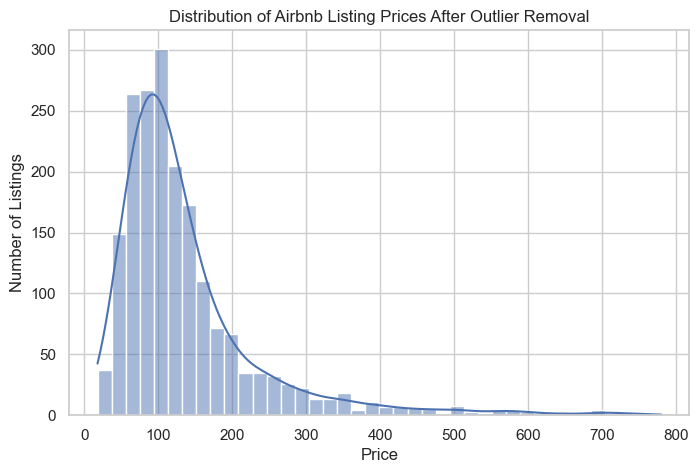

In [14]:
# PART 2.2: PRICE DISTRIBUTION AFTER OUTLIER REMOVAL

plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=40, kde=True)

plt.title("Distribution of Airbnb Listing Prices After Outlier Removal")
plt.xlabel("Price")
plt.ylabel("Number of Listings")

plt.show()

### Price Distribution

The price histogram shows that Airbnb prices in Oakland are still right-skewed after outlier removal. Most listings are priced below about **$200**, while fewer listings are much more expensive. This supports the use of a **log transformation** later in the regression section because log transformations help reduce the effect of a long right tail.

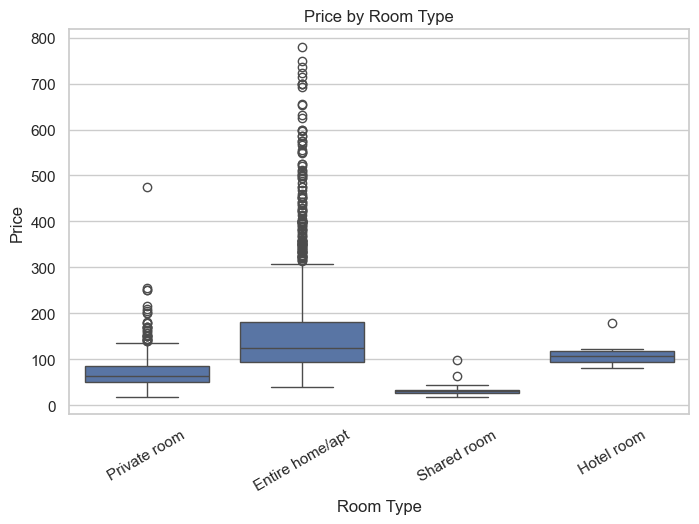

In [15]:
# PART 2.3: BOXPLOT OF PRICE BY ROOM TYPE

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="room_type", y="price")

plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")

plt.xticks(rotation=30)
plt.show()

### Price by Room Type

The boxplot of price by room type shows that **Entire home/apt** listings generally have the highest prices. **Private rooms** are noticeably cheaper, while **Shared rooms** have the lowest prices. Because the price differences between room types are clear, room type appears to be one of the strongest categorical predictors of Airbnb price.

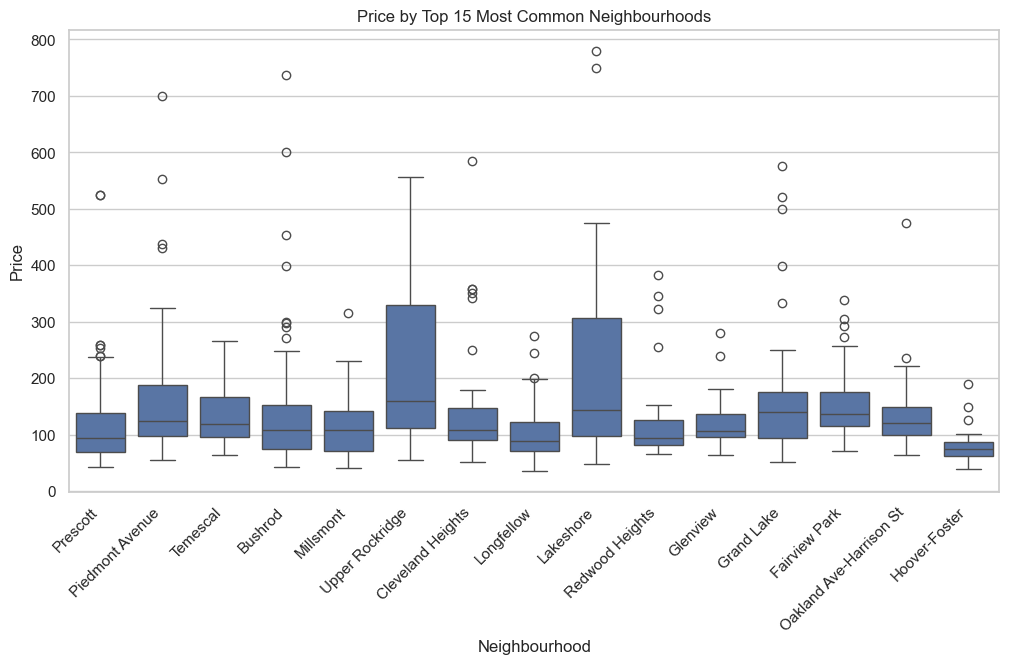

In [16]:
# PART 2.4: BOXPLOT OF PRICE BY TOP 15 NEIGHBOURHOODS

top_15_neighbourhoods = df["neighbourhood"].value_counts().head(15).index

df_top_neighbourhoods = df[df["neighbourhood"].isin(top_15_neighbourhoods)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_neighbourhoods, x="neighbourhood", y="price")

plt.title("Price by Top 15 Most Common Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Price")

plt.xticks(rotation=45, ha="right")
plt.show()

### Price by Neighbourhood

The boxplot of price by the top 15 neighbourhoods shows that prices vary across neighbourhoods. Some neighbourhoods have higher median prices and more high-price outliers, while others are concentrated at lower prices. However, there is also a lot of variation within each neighbourhood, so neighbourhood alone does not fully explain price differences.

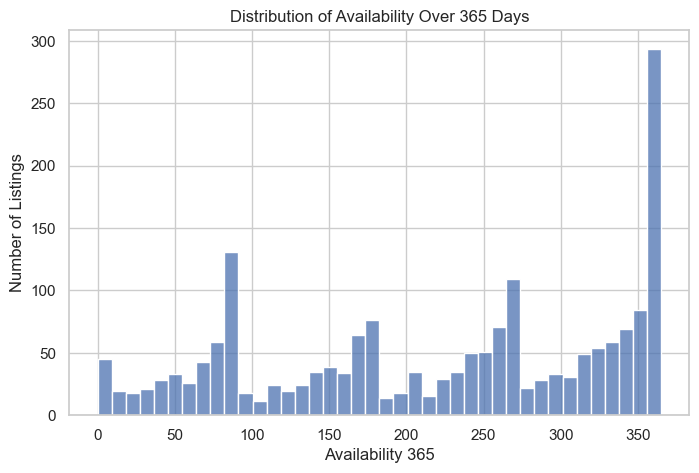

In [17]:
# PART 2.5: HISTOGRAM OF AVAILABILITY_365

plt.figure(figsize=(8, 5))
sns.histplot(df["availability_365"], bins=40)

plt.title("Distribution of Availability Over 365 Days")
plt.xlabel("Availability 365")
plt.ylabel("Number of Listings")

plt.show()

### Availability Distribution

The availability histogram shows that listings are unevenly distributed across the year. Some listings have very low availability, while many listings are available for most of the year. This may reflect different types of Airbnb listings: some may be frequently booked or only occasionally available, while others may operate more like year-round rental properties.

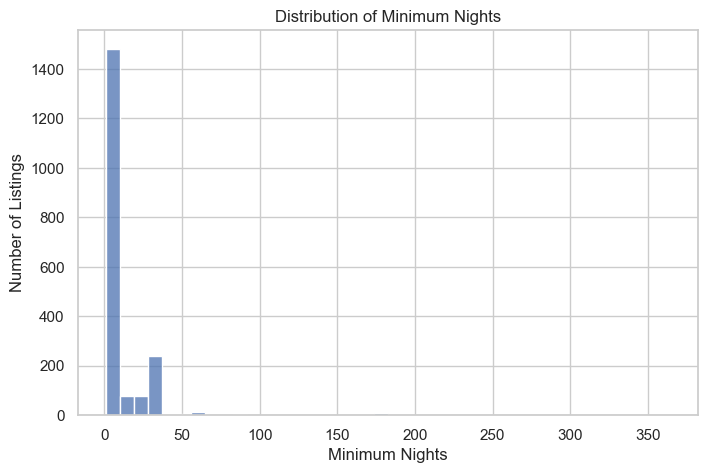

Mean minimum nights: 9.574856546687533
Median minimum nights: 3.0


In [18]:
# PART 2.6: HISTOGRAM OF MINIMUM_NIGHTS

plt.figure(figsize=(8, 5))
sns.histplot(df["minimum_nights"], bins=40)

plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")

plt.show()

print("Mean minimum nights:", df["minimum_nights"].mean())
print("Median minimum nights:", df["minimum_nights"].median())

### Minimum Nights Distribution

The minimum nights distribution is heavily right-skewed. Most listings require only a few nights, but some listings require much longer stays. This explains why the mean minimum nights value is much larger than the median. Because of this skew, minimum_nights may not have a strong simple linear relationship with price.


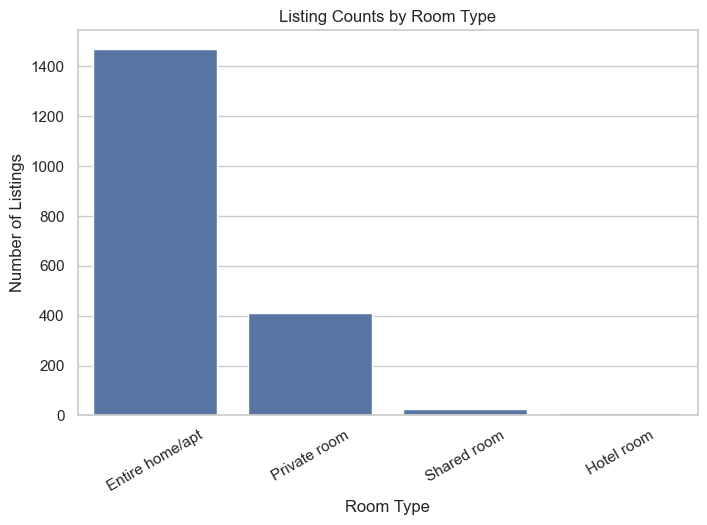

room_type
Entire home/apt    1471
Private room        411
Shared room          25
Hotel room           10
Name: count, dtype: int64

In [19]:
# PART 2.7: BAR CHART OF LISTING COUNTS BY ROOM TYPE

room_type_counts = df["room_type"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=room_type_counts.index, y=room_type_counts.values)

plt.title("Listing Counts by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.xticks(rotation=30)
plt.show()

room_type_counts

### Listing Counts by Room Type

The room type count chart shows that the dataset is dominated by **Entire home/apt** listings, with **1,471 listings**. There are **411 Private room** listings, but only **25 Shared room** listings and **10 Hotel room** listings. Because Shared room and Hotel room have very small sample sizes, it makes sense to combine them into an **Other** category for regression modeling.

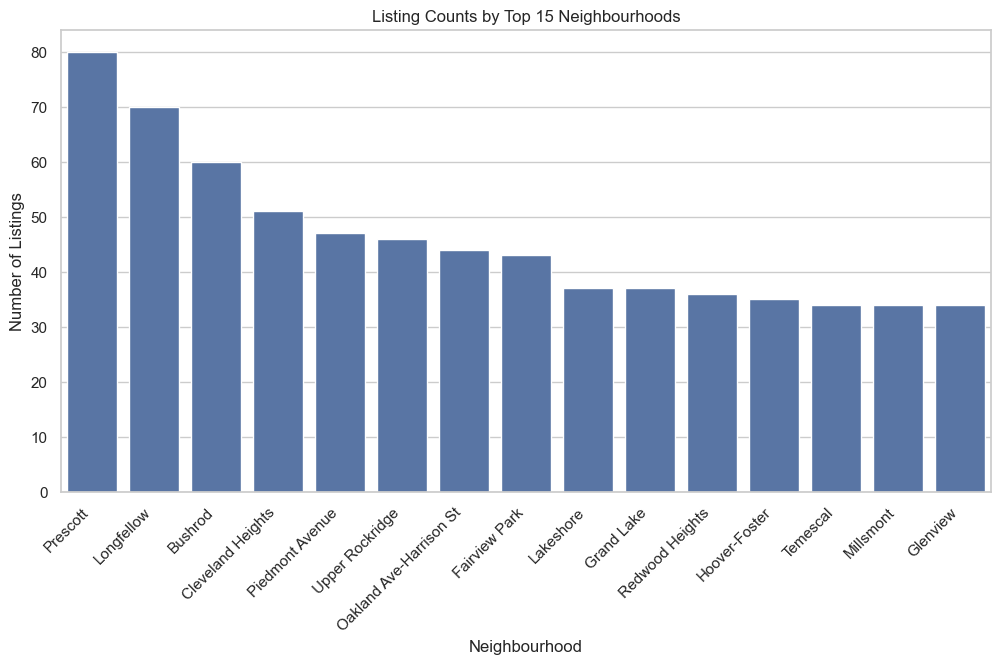

neighbourhood
Prescott                   80
Longfellow                 70
Bushrod                    60
Cleveland Heights          51
Piedmont Avenue            47
Upper Rockridge            46
Oakland Ave-Harrison St    44
Fairview Park              43
Lakeshore                  37
Grand Lake                 37
Redwood Heights            36
Hoover-Foster              35
Temescal                   34
Millsmont                  34
Glenview                   34
Name: count, dtype: int64

In [20]:
# PART 2.8: BAR CHART OF LISTING COUNTS BY TOP 15 NEIGHBOURHOODS

neighbourhood_counts = df["neighbourhood"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=neighbourhood_counts.index, y=neighbourhood_counts.values)

plt.title("Listing Counts by Top 15 Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Number of Listings")

plt.xticks(rotation=45, ha="right")
plt.show()

neighbourhood_counts

### Listing Counts by Neighbourhood

The top 15 neighbourhood count chart shows that listings are not evenly distributed across Oakland. **Prescott** has the most listings, followed by **Longfellow** and **Bushrod**. This means some neighbourhoods are much more represented in the dataset than others, which should be considered when interpreting neighbourhood-level price patterns.


## Part 3: Relationship Exploration — Simran

This section compares variables to one another to see which relationships look useful before regression modeling. The focus is on whether price appears related to availability, minimum nights, review activity, room type, and neighborhood.

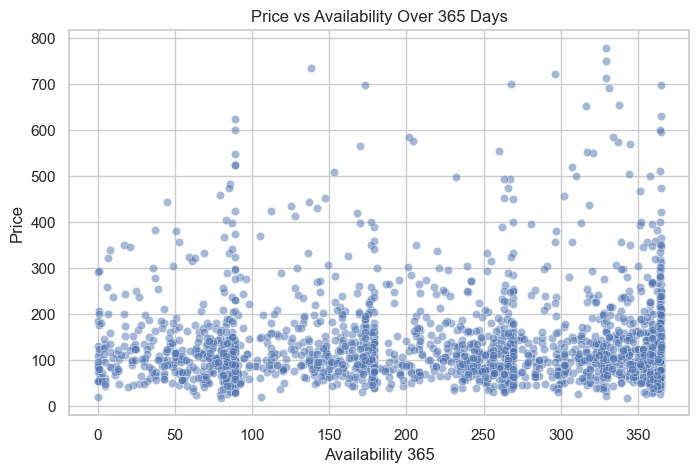

In [21]:
# PART 3.1: SCATTERPLOT OF PRICE VS AVAILABILITY_365

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="availability_365", y="price", alpha=0.5)

plt.title("Price vs Availability Over 365 Days")
plt.xlabel("Availability 365")
plt.ylabel("Price")

plt.show()

### Price vs. Availability

The scatterplot of price versus availability_365 does not show a strong linear relationship. Prices are spread across many availability levels, and both low- and high-priced listings appear at low and high availability values. This suggests that availability alone is probably not a strong predictor of price.


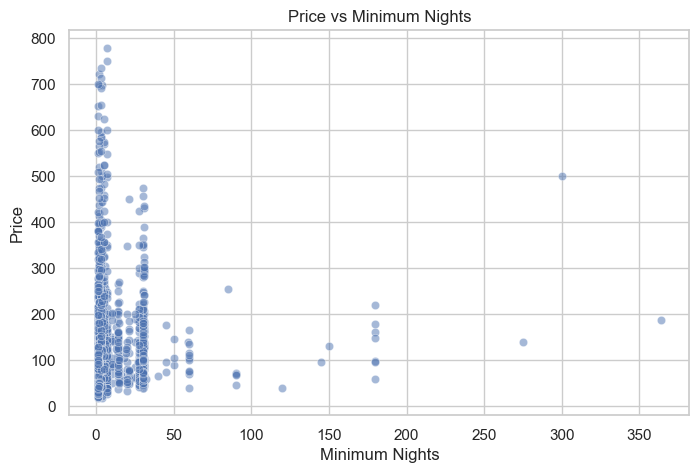

In [22]:
# PART 3.2: SCATTERPLOT OF PRICE VS MINIMUM_NIGHTS

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="minimum_nights", y="price", alpha=0.5)

plt.title("Price vs Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Price")

plt.show()

### Price vs. Minimum Nights

The scatterplot of price versus minimum_nights shows that most listings are clustered at low minimum-night values. There is no clear upward or downward trend between minimum nights and price. This suggests that minimum_nights does not explain much of the variation in price by itself.


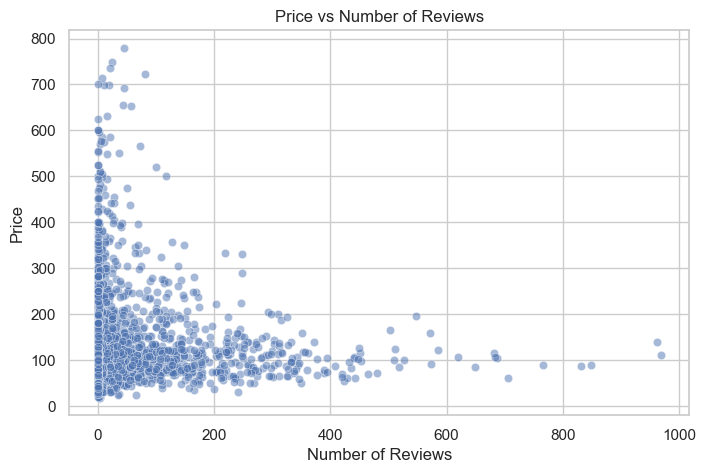

In [23]:
# PART 3.3: SCATTERPLOT OF PRICE VS NUMBER_OF_REVIEWS

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="number_of_reviews", y="price", alpha=0.5)

plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")

plt.show()

### Price vs. Number of Reviews

The scatterplot of price versus number_of_reviews shows a weak negative pattern. Many listings with high review counts are in the lower or middle price range rather than the highest price range. This may suggest that more affordable listings are booked more often and therefore receive more reviews.

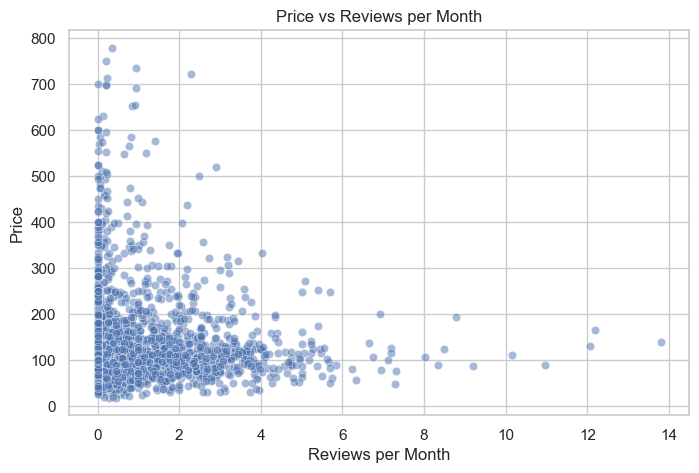

In [24]:
# PART 3.4: SCATTERPLOT OF PRICE VS REVIEWS_PER_MONTH

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="reviews_per_month", y="price", alpha=0.5)

plt.title("Price vs Reviews per Month")
plt.xlabel("Reviews per Month")
plt.ylabel("Price")

plt.show()

### Price vs. Reviews per Month

The scatterplot of price versus reviews_per_month also shows a weak negative relationship. Listings with more reviews per month are not usually the most expensive listings. This suggests that review activity may be more related to booking frequency or affordability than to high prices.

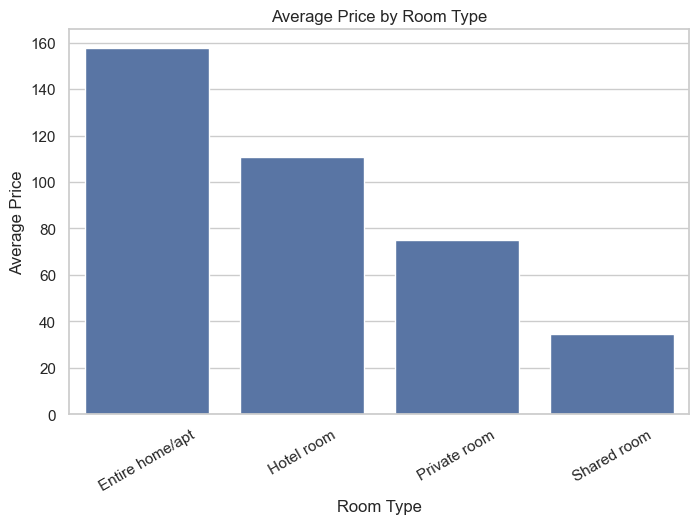

room_type
Entire home/apt    157.777702
Hotel room         110.800000
Private room        74.990268
Shared room         34.560000
Name: price, dtype: float64

In [25]:
# PART 3.5: AVERAGE PRICE BY ROOM TYPE

avg_price_room_type = (
    df.groupby("room_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_price_room_type.index, y=avg_price_room_type.values)

plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")

plt.xticks(rotation=30)
plt.show()

avg_price_room_type

### Average Price by Room Type

The average price by room type shows a clear pattern. **Entire home/apt** listings have the highest average price at about **$157.78**. **Hotel rooms** average about **$110.80**, **Private rooms** average about **$74.99**, and **Shared rooms** average about **$34.56**. This confirms that room type is strongly related to listing price.

In [26]:
# PART 3.6: GROUPED SUMMARY TABLE FOR TOP 15 NEIGHBOURHOODS

top_15_neighbourhoods = df["neighbourhood"].value_counts().head(15).index

neighbourhood_price_summary = (
    df[df["neighbourhood"].isin(top_15_neighbourhoods)]
    .groupby("neighbourhood")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

neighbourhood_price_summary

,count,mean,median
neighbourhood,,,
Lakeshore,37,221.891892,144.0
Upper Rockridge,46,220.978261,158.5
Grand Lake,37,176.162162,139.0
Piedmont Avenue,47,175.255319,124.0
Fairview Park,43,155.232558,136.0
Bushrod,60,146.133333,107.5
Cleveland Heights,51,139.843137,108.0
Temescal,34,133.558824,119.0
Oakland Ave-Harrison St,44,132.454545,120.0


### Mean and Median Price by Neighbourhood

The neighbourhood summary table shows that some neighbourhoods have much higher average prices than others. Among the top 15 neighbourhoods, **Lakeshore** and **Upper Rockridge** have the highest mean prices, both above **$220**. **Hoover-Foster** has the lowest mean price at about **$79.14**. In several neighbourhoods, the mean is higher than the median, which suggests that high-priced listings are pulling the averages upward.

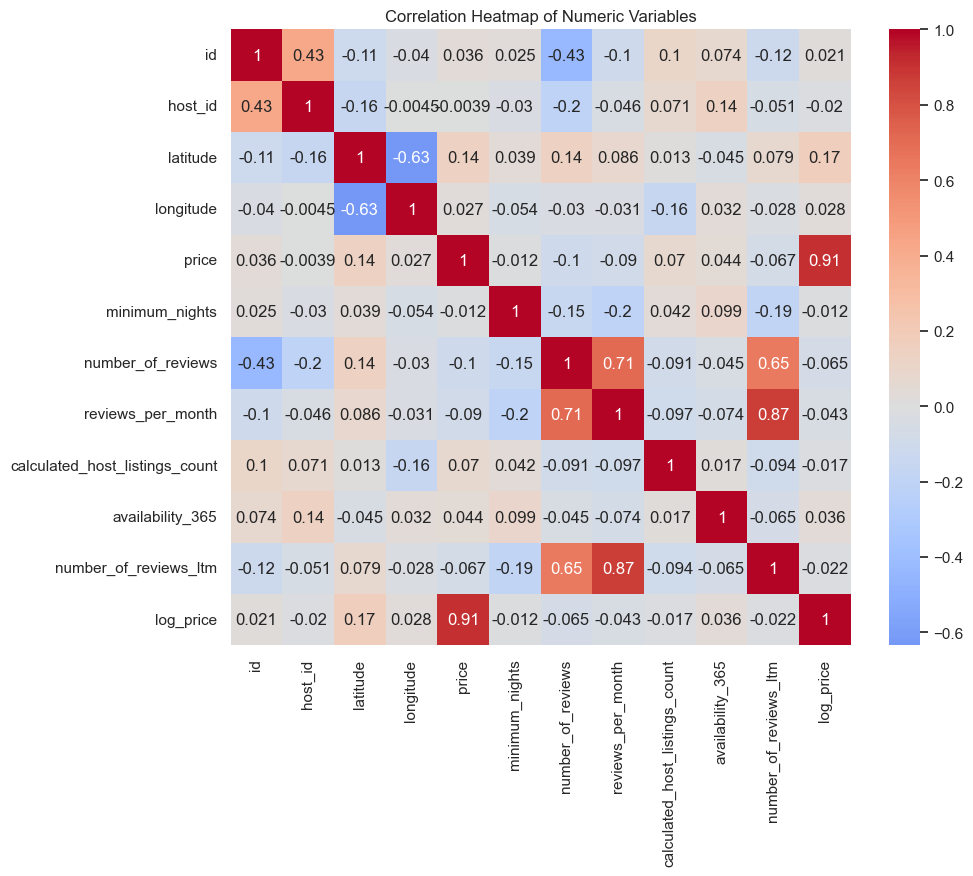

In [27]:
# PART 3.7: CORRELATION HEATMAP OF NUMERIC VARIABLES

numeric_df = df.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)

plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

### Correlation Heatmap

The correlation heatmap shows that most numeric variables have weak correlations with price. This matches the scatterplots, where availability_365, minimum_nights, number_of_reviews, and reviews_per_month do not show strong individual relationships with price. However, these variables may still be useful in a multiple regression model when combined with room type and other predictors.

### Part 3 Written Findings

The relationship plots suggest that room type is the strongest visual predictor of price. Neighbourhood may also matter, but there is a lot of variation within neighbourhoods. The numeric variables, including availability, minimum nights, and review activity, show weak individual relationships with price, but they are still worth testing together in the regression model.

**Does availability correlate with price?** The scatterplot of `price` and `availability_365` does not show a strong relationship. The visual pattern is close to flat, and the correlation is small and positive. This suggests that availability alone is probably not a strong predictor of price.

**Is there a pattern between price and minimum nights?** The `minimum_nights` plot is heavily concentrated at low minimum-night values. Most listings require only a few nights, while a smaller number require much longer stays. The relationship with price looks weak, so minimum nights by itself does not appear to explain much of the price difference.

**Is review activity linked to price?** Both `number_of_reviews` and `reviews_per_month` appear to have weak negative relationships with price. Lower-priced listings may receive more review activity because they are more frequently booked or more affordable, but the scatterplots are very spread out. Review variables may help a regression model slightly, but they do not look like strong predictors on their own.

**Do room type and neighborhood matter?** Room type looks much more promising. Entire homes/apartments have the highest average and median prices, private rooms are lower, and shared rooms are the lowest. Neighborhood also shows differences in average and median price, but there is a lot of variation within neighborhoods. This means neighborhood may matter, but it should be interpreted carefully.

**Which variables look most promising for regression?** Based on the visualizations, `room_type` is the strongest candidate because the price differences between categories are clear. `neighbourhood` may also be useful, although there are many categories. The numeric variables have weak correlations with price, but `availability_365`, `reviews_per_month`, `minimum_nights`, and `calculated_host_listings_count` are still worth testing in regression because their combined effects may explain more than each variable alone.

## Part 4: Regression Modeling — Chesney

This section uses simple linear regression and multiple linear regression to model Airbnb listing price. Because price is right-skewed, the model is also rerun using `log_price` to compare whether the transformed response improves model fit and diagnostics.

In [28]:
# Group rare room type categories
df['room_type_grouped'] = df['room_type'].replace({
    'Shared room': 'Other',
    'Hotel room': 'Other'
})

# Check counts
print(df['room_type_grouped'].value_counts())

df.head()

room_type_grouped
Entire home/apt    1471
Private room        411
Other                35
Name: count, dtype: int64


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,room_type_grouped,log_price
0,3083,Room #2 - West Oakland,3518,Traci,Prescott,37.810130,-122.292660,Private room,125.0,1,78,2025-08-28,0.57,7,87,12,Private room,4.828314
1,5739,Mod Studio,9276,Leah And Gyorgy,Adams Point,37.812663,-122.258047,Entire home/apt,95.0,4,333,2025-08-18,1.69,1,243,6,Entire home/apt,4.553877
2,24916,Studio w/garden and Patio close to Rockridge,98716,Judy,Piedmont Avenue,37.831690,-122.251750,Entire home/apt,92.0,4,147,2025-09-01,0.79,2,194,2,Entire home/apt,4.521789
3,29521,Elegant Rockridge Home,124220,Kymi,Shafter,37.836180,-122.255810,Entire home/apt,250.0,5,50,2025-08-07,0.29,1,25,9,Entire home/apt,5.521461
4,30026,Temescal sunny townhome w/views every room 3 d...,98716,Judy,Temescal,37.834500,-122.262640,Entire home/apt,167.0,21,4,2023-06-12,0.03,2,269,0,Entire home/apt,5.117994


In [29]:
# SLR: price ~ availability_365
model_slr1 = smf.ols('price ~ availability_365', data=df).fit()
print(model_slr1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.674
Date:                Wed, 10 Jun 2026   Prob (F-statistic):             0.0554
Time:                        19:04:36   Log-Likelihood:                -11572.
No. Observations:                1917   AIC:                         2.315e+04
Df Residuals:                    1915   BIC:                         2.316e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          129.4725      5.097  

## Simple Linear Regression: Price and Availability Interpretations

### Intercept: 129.47

The intercept means that the predicted price for a listing with `availability_365 = 0` is about **$129**.

This means the model predicts a listing that is never available during the year would have a price of around **$129**. This is not very meaningful on its own, but it acts as the baseline value for the model.

### Availability 365 Coefficient: 0.0392

The coefficient for `availability_365` is **0.0392**.

This means that for each additional day a listing is available during the year, the predicted price is expected to increase by about **$0.04**.

This is a very small effect. For example, a listing available for 365 days compared to 0 days would only be predicted to cost about **$14 more**.

### P-value: 0.055

The p-value is **0.055**, which is just above the common 0.05 cutoff.

This means that `availability_365` is **not statistically significant at the 5% level**. There is not enough evidence to conclude that annual availability has a meaningful linear relationship with price.

### R-squared: 0.002

The R-squared value is **0.002**.

This means that `availability_365` explains only about **0.2% of the variation in price**. This is an extremely poor fit, meaning availability alone does not explain price very well.

### F-statistic P-value: 0.055

The F-statistic p-value is also **0.055**.

This matches the p-value for `availability_365` and confirms that the model as a whole is **not statistically significant at the 5% level**.

Overall, `availability_365` does not appear to be a strong predictor of price in this model.


In [30]:
# SLR: price ~ minimum_nights
model_slr2 = smf.ols('price ~ minimum_nights', data=df).fit()
print(model_slr2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2675
Date:                Wed, 10 Jun 2026   Prob (F-statistic):              0.605
Time:                        19:04:36   Log-Likelihood:                -11574.
No. Observations:                1917   AIC:                         2.315e+04
Df Residuals:                    1915   BIC:                         2.316e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        138.7364      2.556     54.

## Simple Linear Regression: Price and Minimum Nights Interpretations

### Intercept: 138.74

The intercept means that the predicted price for a listing with `minimum_nights = 0` is about **$139**.

This is not physically meaningful because a listing cannot realistically have a minimum stay of 0 nights. However, it still serves as the baseline value for the model.

### Minimum Nights Coefficient: -0.0585

The coefficient for `minimum_nights` is **-0.0585**.

This means that for each additional night added to the minimum stay requirement, the predicted price is expected to decrease by about **$0.06**.

This is a very small effect. For example, a listing requiring 30 minimum nights would only be predicted to cost about **$1.75 less** than a listing requiring 1 minimum night.

### P-value: 0.605

The p-value is **0.605**, which is greater than 0.05.

This means that `minimum_nights` is **not statistically significant**. We do not have enough evidence to say that minimum nights has a meaningful linear relationship with price.

### R-squared: 0.000

The R-squared value is **0.000**.

This means that `minimum_nights` explains essentially **0% of the variation in price**. In other words, this variable does not help explain differences in listing prices.

### Adjusted R-squared: -0.000

The adjusted R-squared value is slightly negative.

This means the model is no better than simply predicting the average price for every listing.

### F-statistic P-value: 0.605

The F-statistic p-value is also **0.605**.

This confirms that the model as a whole is **not statistically significant**. Overall, `minimum_nights` does not appear to be a useful predictor of price in this model.


## Conclusion from both SLR Models
Neither variable on its own is a useful predictor of price. This is exactly why we move to MLR, as combining multiple 
predictors together is likely where the explanatory power will come from.


In [31]:
# Multiple Linear Regression (grouped room type dummies in the formula via C() so statsmodels handles encoding automatically, as done in
# lab 07)
model_mlr = smf.ols(
    'price ~ C(room_type_grouped) + availability_365 + minimum_nights '
    '+ reviews_per_month + calculated_host_listings_count',
    data=df
).fit()
print(model_mlr.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     60.93
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           2.73e-69
Time:                        19:04:36   Log-Likelihood:                -11406.
No. Observations:                1917   AIC:                         2.283e+04
Df Residuals:                    1910   BIC:                         2.286e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


## Multiple Linear Regression Results

The multiple linear regression model improves on the simple linear regression models. The model has an **R² of 0.161**, meaning it explains about **16.1% of the variation in listing price**. This is an improvement compared to the simple linear regression models, which explained almost none of the variation in price. The **adjusted R² is 0.158**, which is very close to the R² value. This suggests that the additional predictors are contributing useful information rather than only inflating the model fit.

The overall model is statistically significant, with an **F-statistic p-value of 2.73e-69**. Since this p-value is extremely small, we can conclude that the model as a whole is significant.

### Intercept: 152.66

The intercept represents the predicted price for the baseline category, which is an **Entire home/apt**, when all continuous predictors are equal to zero. Although this baseline may not be practically meaningful in real life, it gives the model a reference point for comparing other room types.

### Room Type Effects

Compared to an **Entire home/apt**, listings classified as **Other** are predicted to cost about **$124.58 less**, holding all other variables constant. This result is statistically significant with **p < 0.001**. Since the “Other” category includes shared rooms and hotel rooms, this suggests that these listings tend to be much cheaper than entire homes or apartments.

Private rooms are predicted to cost about **$90.21 less** than entire homes or apartments, holding all other variables constant. This result is also statistically significant with **p < 0.001**. This shows that room type is one of the strongest predictors of Airbnb price in this model.

### Availability

The coefficient for **availability_365** is **0.0597**, with a **p-value of 0.002**. This means availability is statistically significant in the multiple regression model. For each additional day a listing is available during the year, the predicted price increases by about **$0.06**, holding all other variables constant. This is a small effect, but it becomes significant after controlling for other predictors.

### Minimum Nights

The coefficient for **minimum_nights** is **-0.3248**, with a **p-value of 0.002**. This means minimum nights is statistically significant. For each additional required minimum night, the predicted price decreases by about **$0.32**, holding all other variables constant. This suggests that listings requiring longer stays may be slightly cheaper per night.

### Reviews per Month

The coefficient for **reviews_per_month** is **-9.699**, with **p < 0.001**. This means reviews per month is statistically significant. For each additional review per month, the predicted price decreases by about **$9.70**, holding all other variables constant.

This may suggest that cheaper listings are booked more often and therefore receive more reviews. In other words, more reviews do not necessarily mean a listing is more expensive; instead, review activity may reflect booking frequency.

### Host Listing Count

The coefficient for **calculated_host_listings_count** is **2.642**, with **p < 0.001**. This means host listing count is statistically significant. For each additional listing managed by a host, the predicted price increases by about **$2.64**, holding all other variables constant.

This may suggest that hosts with more listings, such as professional or commercial Airbnb hosts, tend to charge slightly higher prices.

### Overall Interpretation

Every predictor in the multiple linear regression model is statistically significant. However, **room type appears to be the strongest driver of price**, especially because entire homes or apartments are much more expensive than private rooms, shared rooms, or hotel rooms.

Even though the model is statistically significant, the R² value of **16.1%** is still fairly low. This means the model explains some variation in Airbnb prices, but most of the variation is still unexplained. This is expected because Airbnb prices are likely influenced by many other factors that are not included in the dataset, such as exact location quality, amenities, photos, property size, cleaning fees, host reputation, and seasonality.


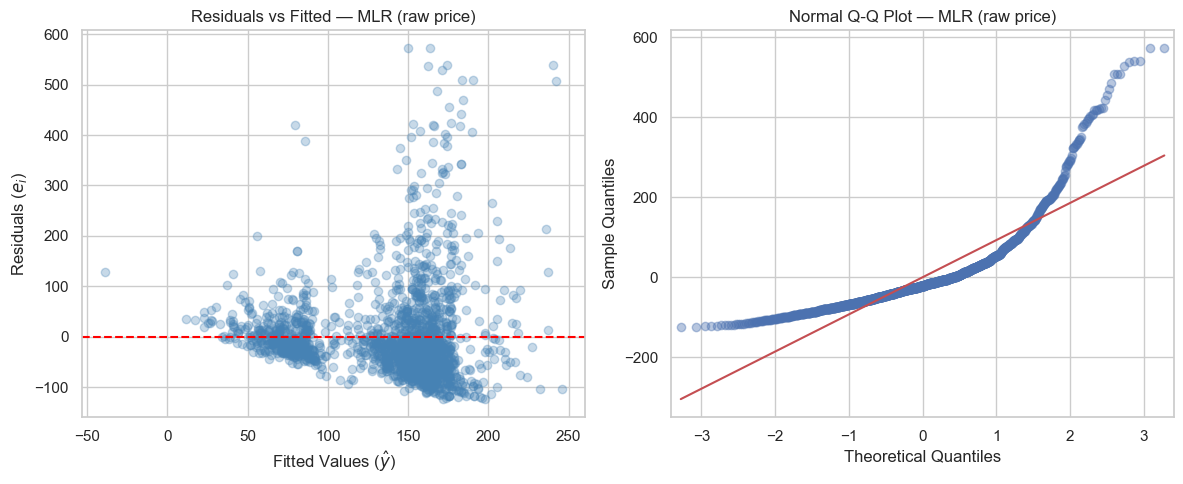

In [32]:
# Model Assumption Diagnostics: Residuals vs Fitted, Q-Q Plot
from statsmodels.graphics.gofplots import qqplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs Fitted
axes[0].scatter(model_mlr.fittedvalues, model_mlr.resid, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Fitted Values ($\\hat{y}$)')
axes[0].set_ylabel('Residuals ($e_i$)')
axes[0].set_title('Residuals vs Fitted — MLR (raw price)')

# Q-Q plot
qqplot(model_mlr.resid, line='s', ax=axes[1], alpha=0.4)
axes[1].set_title('Normal Q-Q Plot — MLR (raw price)')

plt.tight_layout()
plt.show()

## Regression Diagnostic Plot Conclusions

### Residuals vs. Fitted Plot

The residuals vs. fitted plot shows a clear **fan shape**, where the spread of the residuals becomes wider as the fitted values increase. At higher fitted values, there are large positive residuals, reaching up to about **$575**, while the negative residuals have a much smaller lower limit because prices cannot go below zero.

This means the residuals are not randomly scattered around zero. Instead, the model appears to **under-predict higher-priced listings**, producing large positive residuals for more expensive Airbnbs. This pattern suggests that the model violates the **homoscedasticity assumption**, which requires the residuals to have constant variance across fitted values.

### Normal Q-Q Plot

The Normal Q-Q plot shows that the points follow the diagonal line reasonably well in the middle of the distribution. However, both tails deviate noticeably from the line. The left tail curves below the line, while the right tail curves above it, creating an S-shaped pattern.

This indicates that the residuals have **heavy tails** and are still affected by **right skew**. Therefore, the residuals do not fully satisfy the normality assumption. This also matches the model summary, where the residuals had a skewness of **2.579** and kurtosis of **12.125**.

### Final Diagnostic Conclusion

Overall, the diagnostic plots show that the regular multiple linear regression model does not fully satisfy the assumptions of **constant variance** and **normally distributed residuals**. This is expected because Airbnb prices are heavily right-skewed, with a small number of listings having much higher prices than the majority.

These issues motivate using a **log transformation of price** in the next model. Taking the log of price helps compress the right tail of the distribution, which may lead to more stable residual variance and a model that better satisfies the assumptions of linear regression.


In [33]:
# Re-run MLR with log price
model_log = smf.ols(
    'log_price ~ C(room_type_grouped) + availability_365 + minimum_nights '
    '+ reviews_per_month + calculated_host_listings_count',
    data=df
).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     138.1
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          1.57e-145
Time:                        19:04:36   Log-Likelihood:                -1360.7
No. Observations:                1917   AIC:                             2735.
Df Residuals:                    1910   BIC:                             2774.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


## Results

### Model Fit

### R-squared: 0.303

The R-squared value is **0.303**.

This means that the log-transformed model explains about **30.3% of the variation in log price**.

This is a clear improvement compared to the raw price model, which explained only about **16.1%** of the variation. In other words, using `log(price)` helped the model fit the data better.

### Adjusted R-squared: 0.300

The adjusted R-squared value is **0.300**.

This confirms that the improvement is genuine and not just caused by adding more predictors to the model.

### F-statistic P-value: 1.57e-145

The F-statistic p-value is **1.57e-145**, which is extremely small.

This means the model as a whole is **highly statistically significant**. At least one of the predictors is meaningfully related to `log(price)`.

## Coefficient Interpretations

### Intercept: 4.89

The intercept is **4.89** on the log scale.

This represents the predicted log price for the baseline category, which is an **entire home/apartment**, when the numeric predictors are equal to 0.

Back-transforming gives:

`e^4.89 ≈ 133`

So, the predicted baseline price is about **$133**.

### Other Room Type Coefficient: -1.164

The coefficient for `Other` room types is **-1.164**, and it is statistically significant with **p < 0.001**.

This means shared or hotel-style rooms have a predicted log price about **1.16 lower** than entire homes/apartments.

Back-transforming gives:

`e^-1.164 ≈ 0.31`

This means these listings cost about **31% as much as entire homes**, or about **69% less**.

### Private Room Coefficient: -0.732

The coefficient for `Private room` is **-0.732**, and it is statistically significant with **p < 0.001**.

Back-transforming gives:

`e^-0.732 ≈ 0.48`

This means private rooms cost about **48% as much as entire homes**, or about **52% less**.

### Availability 365 Coefficient: 0.0004

The coefficient for `availability_365` is **0.0004**, and it is statistically significant with **p < 0.001**.

This means that listings with more available days during the year are associated with slightly higher log prices.

However, the effect is very small, so availability is statistically significant but not a very strong practical predictor.

### Minimum Nights Coefficient: -0.0019

The coefficient for `minimum_nights` is **-0.0019**, with **p = 0.001**.

This means that longer minimum stay requirements are associated with slightly lower log prices.

The relationship is statistically significant, but the size of the effect is small.

### Reviews Per Month Coefficient: -0.0489

The coefficient for `reviews_per_month` is **-0.0489**, and it is statistically significant with **p < 0.001**.

This means that each additional review per month is associated with about a **4.8% lower price**.

This could suggest that lower-priced listings receive more frequent bookings and therefore more reviews.

### Calculated Host Listings Count Coefficient: 0.0061

The coefficient for `calculated_host_listings_count` is **0.0061**, with **p = 0.038**.

This is the weakest predictor in the model, but it is still statistically significant at the 5% level.

This means that hosts with more listings tend to charge slightly higher prices, possibly because professional or large-scale hosts may manage more expensive listings.

## Overall Interpretation

Overall, the log-transformed model performs better than the raw price model. It explains more variation in price and has stronger statistical significance.

The most important predictors appear to be **room type**, especially private rooms and other room types compared to entire homes/apartments. Other variables, such as availability, minimum nights, reviews per month, and host listing count, are statistically significant but have smaller effects.


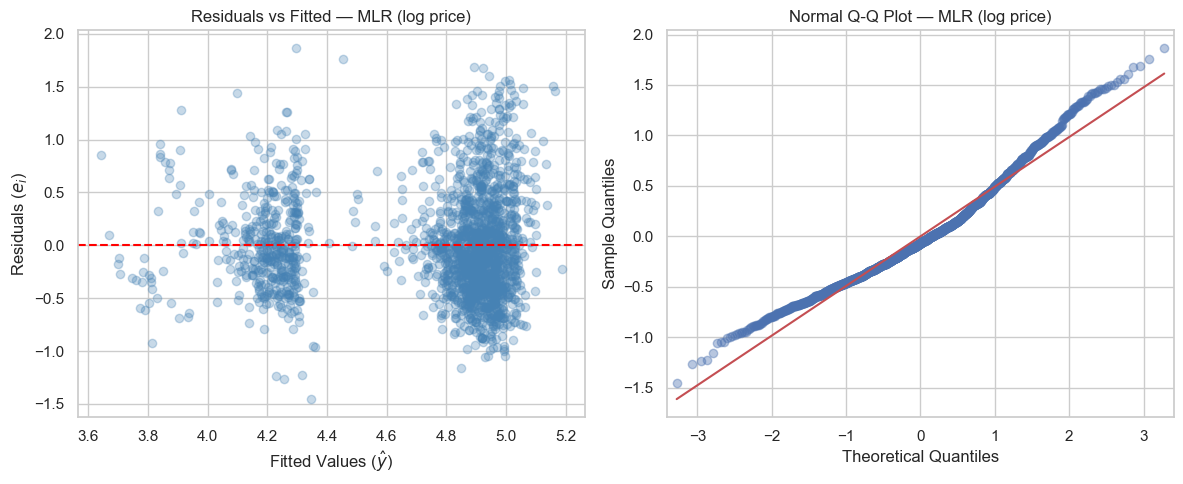

In [34]:
# Diagnostic plots
from statsmodels.graphics.gofplots import qqplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(model_log.fittedvalues, model_log.resid, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Fitted Values ($\\hat{y}$)')
axes[0].set_ylabel('Residuals ($e_i$)')
axes[0].set_title('Residuals vs Fitted — MLR (log price)')

qqplot(model_log.resid, line='s', ax=axes[1], alpha=0.4)
axes[1].set_title('Normal Q-Q Plot — MLR (log price)')

plt.tight_layout()
plt.show()


## Results

## Diagnostic Plot Interpretations

### Residuals vs. Fitted Plot

The fan shape from the raw price model is mostly gone. This means the residuals are now much more evenly spread around zero across the range of fitted values.

There is a noticeable gap around a fitted value of about **4.6**. This likely reflects the two clusters of room types in the data:

* Entire homes/apartments are fitted around **4.9**
* Private rooms and other room types are fitted around **4.1**

This gap is structural and is not a major problem with the model.

A few outliers still remain, but they are much less extreme than in the raw price model. For example, the raw price model had residuals as large as about **$575**, while the log-transformed model reduces the impact of those extreme values.

### Normal Q-Q Plot

The points in the Normal Q-Q plot follow the diagonal line much more closely compared to the raw price model.

There is still mild deviation at both tails, meaning the residuals are not perfectly normal. However, this is much better than the severe S-curve seen in the raw price model.

Overall, the residuals are approximately normal, and the log-transformed model shows a clear improvement over the raw price model.


## Overall Conclusion from the Log Transformation

The log transformation substantially improves the regression model. Compared to the original multiple linear regression model using raw price, the log-transformed model provides a better fit and helps address some of the assumption problems seen in the diagnostic plots.

Because Airbnb prices are heavily right-skewed, using `log_price` compresses the extreme high-price values and makes the response variable more balanced. This reduces the influence of unusually expensive listings and helps the residuals behave more consistently.

Overall, the log transformation improves the model in three main ways: it increases model fit, makes the regression results more reliable, and helps the model better satisfy the assumptions of linear regression. For this reason, the log-transformed model is more appropriate for analyzing Airbnb listing prices than the original raw-price model.


In [35]:
##### SUMMARY: R^2, Adjusted R^2, and P-values (as seen in lab07) ######
# Summary comparison table
results_table = pd.DataFrame({
    'Model': [
        'SLR: availability_365',
        'SLR: minimum_nights',
        'MLR (raw price)',
        'MLR (log price)'
    ],
    'R²': [
        model_slr1.rsquared,
        model_slr2.rsquared,
        model_mlr.rsquared,
        model_log.rsquared
    ],
    'Adj. R²': [
        model_slr1.rsquared_adj,
        model_slr2.rsquared_adj,
        model_mlr.rsquared_adj,
        model_log.rsquared_adj
    ],
    'F p-value': [
        model_slr1.f_pvalue,
        model_slr2.f_pvalue,
        model_mlr.f_pvalue,
        model_log.f_pvalue
    ]
}).round(4)

print("=== Model Comparison ===")
print(results_table.to_string(index=False))

# P-values for each predictor in both MLR models
print("\n=== MLR (raw price) — Predictor P-values ===")
print(model_mlr.pvalues.round(4))

print("\n=== MLR (log price) — Predictor P-values ===")
print(model_log.pvalues.round(4))

=== Model Comparison ===
                Model     R²  Adj. R²  F p-value
SLR: availability_365 0.0019   0.0014     0.0554
  SLR: minimum_nights 0.0001  -0.0004     0.6051
      MLR (raw price) 0.1607   0.1580     0.0000
      MLR (log price) 0.3025   0.3003     0.0000

=== MLR (raw price) — Predictor P-values ===
Intercept                               0.0000
C(room_type_grouped)[T.Other]           0.0000
C(room_type_grouped)[T.Private room]    0.0000
availability_365                        0.0016
minimum_nights                          0.0024
reviews_per_month                       0.0000
calculated_host_listings_count          0.0000
dtype: float64

=== MLR (log price) — Predictor P-values ===
Intercept                               0.0000
C(room_type_grouped)[T.Other]           0.0000
C(room_type_grouped)[T.Private room]    0.0000
availability_365                        0.0001
minimum_nights                          0.0007
reviews_per_month                       0.0000
calculated_h

## Overall Summary From Linear Regression Results

The regression analysis examined the relationship between Airbnb listing price and five predictor variables: room type, availability, minimum nights, reviews per month, and host listing count. The two simple linear regression models revealed that neither `availability_365` (R^2 = 0.002, p = 0.055) nor `minimum_nights` (R^2 = 0.000, p = 0.605) were meaningful individual predictors of price, each explaining essentially none of the variance in price on their own.

The multiple linear regression model incorporating all five predictors performed better, achieving an adjusted R^2 of 0.158 on the raw price scale. Every predictor was statistically significant (all p < 0.01), with room type emerging as the dominant driver of price. Private rooms were associated with around 90 dollars lower prices than entire homes, and shared/hotel rooms around 125 dollars lower, holding all other variables fixed. However, residual diagnostics revealed clear violations of the OLS assumptions of homoscedasticity and normality, with a pronounced fan shape in the residuals vs fitted plot and heavy tail deviation in the Q-Q plot, both attributable to the right-skewed distribution of price.

After log-transforming price, the model improved considerably. Adjusted R^2 increased to 0.300, skewness dropped from 2.58 to 0.71, and the residual plots were substantially more well-behaved. All predictors remained significant in the log model. Room type remained the strongest predictor: private rooms cost approximately 52% less than entire homes and shared/hotel rooms approximately 69% less. Reviews per month showed a consistent negative association with price (p < 0.001), potentially reflecting that more affordable listings attract more frequent bookings. Availability and minimum nights showed small but significant effects, and host listing count was the weakest predictor (p = 0.038) but remained significant. 

Overall, while the log-price model explains 30% of the variation in log listing price, the remaining 70% variation is likely driven by unobserved factors such as precise location, amenities, listing quality, and host reputation that are not captured in the available variables.